# Tarea 1: el retrato de tu comuna

**INF-396 Introducción a la Ciencia de Datos** · Universidad Técnica Federico Santa María

| | |
|---|---|
| **Integrante 1** | Gabriel Delgado Rodriguez |
| **Comuna** | Maipu |
| **Comuna de contraste** | La Florida |

**Antes de empezar**

1. El archivo se entrega con el nombre `tarea1_apellido1_apellido2.ipynb`.
2. El notebook debe correr **de principio a fin** en el entorno del curso
   (`uv sync`), leyendo los datos desde `datos/eod_stgo/`.
3. Cada ítem tiene tres partes: las instrucciones, una o más celdas de código,
   y una celda de **Interpretación** donde va su respuesta. Un resultado
   correcto sin interpretación no otorga el puntaje completo.

**Regla transversal de la tarea**

Toda cifra que hable de la población debe estar **ponderada por el factor de
expansión que corresponde a la unidad analizada**, usando como universo mínimo el
**día laboral de temporada normal**: `Factor` para hogares,
`Factor_LaboralNormal` para personas y `FactorLaboralNormal` para viajes (los dos
últimos difieren solo en un guion bajo). Si deciden ampliar el universo (fin de
semana, temporada estival), deben declararlo y usar los factores correspondientes.
Una cifra muestral presentada como poblacional, o una cifra que no declara su
universo, descuenta en el ítem.

## 0. Configuración

Esta celda deja listo lo que usarán en toda la tarea: las tres tablas
principales, la edad y el universo de día laboral. **Completen su comuna y
ejecútenla antes que todo lo demás.** Los nombres de comuna vienen en mayúsculas
y sin tildes (por ejemplo `"ESTACION CENTRAL"`).

Pandas no trae cuantiles ponderados: implementarlos es parte de la tarea.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA = "../cienciadatos/datos/eod_stgo/" #modifique la ruta ver

MI_COMUNA = "MAIPU"        # en mayusculas, como en Hogares.csv
COMUNA_CONTRASTE = "ÑUÑOA"

hogares = pd.read_csv(RUTA + "Hogares.csv", sep=";", decimal=",", low_memory=False)
personas = pd.read_csv(RUTA + "personas.csv", sep=";", decimal=",", low_memory=False)
viajes = pd.read_csv(RUTA + "viajes.csv", sep=";", decimal=",", low_memory=False)

# La encuesta registra el anio de nacimiento; la edad se calcula al 2013.
personas["Edad"] = 2013 - personas["AnoNac"]

# Universo minimo de la tarea: dia laboral de temporada normal.
# El factor viene vacio (NaN) para quienes no pertenecen a ese universo
# (encuestados de fin de semana y de temporada estival): el filtro los excluye.
personas_lab = personas.dropna(subset=["Factor_LaboralNormal"])
viajes_lab = viajes.dropna(subset=["FactorLaboralNormal"])


print(f"hogares: {len(hogares):,} | personas: {len(personas):,} | viajes: {len(viajes):,}")
print(f"universo laboral: {len(personas_lab):,} personas, {len(viajes_lab):,} viajes")


hogares: 18,264 | personas: 60,054 | viajes: 113,591
universo laboral: 37,326 personas, 78,820 viajes


## Parte 1. Retrato numérico (25 puntos)

### 1. La muestra y a quién representa (5 pts)

**Instrucciones**

Reporten cuatro cifras para su comuna: cuántos hogares y cuántas personas fueron
encuestados, y a cuántos hogares y personas representan según los factores de
expansión.

En la interpretación, expliquen en una frase por qué "encuestados" y
"representados" responden preguntas distintas.

In [3]:
# Su código (agreguen las celdas que necesiten)
hogaresMaipu = hogares[hogares["Comuna"] == MI_COMUNA]
hogaresNunoa = hogares[hogares["Comuna"] == COMUNA_CONTRASTE]
len(hogaresMaipu), round(hogaresMaipu["Factor"].sum()), len(hogaresNunoa), round(hogaresNunoa["Factor"].sum())

(1466, 153246, 603, 76526)

In [4]:
personasMaipu = pd.merge(hogaresMaipu, personas, on="Hogar", how="left")
personasNunoa = pd.merge(hogaresNunoa, personas, on="Hogar", how="left")
len(personasMaipu), round(personasMaipu["Factor_y"].sum()), len(personasNunoa), round(personasNunoa["Factor_y"].sum())

(5314, 516375, 1747, 211265)

###  Cifras Muestrales y Expandidas

| Comuna | Hogares Encuestados (Muestra) | Hogares Representados (Expandido) | Personas Encuestadas (Muestra) | Personas Representadas (Expandido) |
| :--- | :---: | :---: | :---: | :---: |
| **Maipú** | 1.466 | 153.245 | 5.314 | 516.375 |
| **La Florida** | 1.039 | 115.075 | 3.321 | 384.580 |

**Interpretación:**  Los encuestados son aquellas personas a quienes se les hizo la encuesta, aquellas personas que fisicamente respondieron la encuesta; los respresentados se traduce en toda la poblacion que representa la respuesta del encuestado, traduciendose en que ese ciudadano se amplifica en muchas personas con la misma situacion

### 2. Composición (6 pts)

**Instrucciones**

Describan la composición de su comuna comparada con la del Gran Santiago:
la distribución por sexo (la proporción ponderada de cada categoría) y la edad
(mediana y percentiles 25 y 75 ponderados), para las dos unidades. La
ponderación usa el factor de la persona, dentro del universo que declararon al
inicio; si trabajan con el mínimo de día laboral, la celda de configuración ya
les deja `personas_lab` filtrado.

En la interpretación, expliquen en qué se parece y en qué difiere la composición
de su comuna respecto de la ciudad.

In [5]:
# Su código (agreguen las celdas que necesiten)
pondHMaipu= personasMaipu[personasMaipu["Sexo"] == 1]["Factor_y"].sum()
pondMMaipu = personasMaipu[personasMaipu["Sexo"] == 2]["Factor_y"].sum()
pondH = personas[personas["Sexo"] == 1]["Factor"].sum()
pondM = personas[personas["Sexo"] == 2]["Factor"].sum()
pondPMaipu = personasMaipu["Factor_y"].sum()
pondP = personas["Factor"].sum()
round(pondHMaipu), round(pondMMaipu),round(pondH), round(pondM)

(246465, 269910, 3258017, 3393718)

In [6]:
round(pondPMaipu), round(pondP)

(516375, 6651735)

In [7]:
porcHMaipu = (pondHMaipu / pondPMaipu)*100
porcMMaipu = (pondMMaipu / pondPMaipu)*100
porcH = (pondH / pondP)*100
porcM = (pondM / pondP)*100
porcHMaipu, porcMMaipu, porcH, porcM

(np.float64(47.729814602535455),
 np.float64(52.270185397464566),
 np.float64(48.979962722845926),
 np.float64(51.020037277154074))

In [8]:
(pondHMaipu/pondH)*100, (pondMMaipu/pondM)*100

(np.float64(7.564872559210027), np.float64(7.953230839531695))

En Maipu la representacion de hombres corresponde a un aproximado de 47% mientras que las mujeres corresponde a la mayoria con un 52%, en cambio en Santiago, la representacion de hombres asciende casi al 49% aumentando en mas de 1 punto. A nivel Santiago, los hombres de Maipu representan en 7.5% meintas que la representacion de mujeres aporta casi un 8% de las mujeres de la comuna

In [9]:
#funcion aux para calcular cuantil ponderado
def cuantil_ponderado(valores, pesos, cuantiles):
    """Cuantiles de una variable con pesos de muestreo."""
    d = pd.DataFrame({"v": valores, "w": pesos}).dropna().sort_values("v")
    acumulada = d["w"].cumsum() / d["w"].sum()
    return [float(d.loc[(acumulada >= q).idxmax(), "v"]) for q in np.atleast_1d(cuantiles)]

In [10]:
cuantil_ponderado(personasMaipu["Edad"], personasMaipu["Factor_y"], [0.25, 0.5, 0.75]), cuantil_ponderado(personas["Edad"], personas["Factor"], [0.25, 0.5, 0.75])

([18.0, 32.0, 51.0], [18.0, 34.0, 52.0])

**Interpretación:** Tanto a nivel comunal como regional las mujeres representan la mayor parte de la poblacion, aunque a nivel maipu las mujeres tienen un mayor porcentaje de poblacion representativa comparandola con el Gran Santiago en mas de de 1 punto. En cuanto a edad ambos tienen un cuantie 25 de 18  años y una diferencia de 1 año en el cuantl 75 con 51 y 52 años a nivel comunal y regional; la mayor diferencia esta en la mediana con 32 y 34 años, indicando que en Maipu la poblacion es ligeramente mas joven en el tramo medio sin variar en significativamente los extremos

### 3. Ingresos (7 pts)

**Instrucciones**

Calculen tres medidas del ingreso de los hogares de su comuna, ponderadas por
`Factor`: la media, la mediana y la media truncada al 10%. Para la truncada,
excluyan el 10% más bajo y el 10% más alto del ingreso (los percentiles
ponderados 10 y 90 definen los cortes) y recalculen la media ponderada con los
hogares restantes. Calculen las mismas tres medidas para la ciudad completa,
como referencia.

En la interpretación, decidan cuál de las tres medidas reportarían como "el
ingreso de la comuna" y justifíquenla a partir de la forma de la distribución de
su comuna, no como regla de memoria.

In [11]:
# Su código (agreguen las celdas que necesiten)
mediaMSueldos = np.average(hogaresMaipu["IngresoHogar"], weights=hogaresMaipu["Factor"])
mediaSueldos = np.average(hogares["IngresoHogar"], weights=hogares["Factor"])
round(mediaMSueldos), round(mediaSueldos)


(595384, 729898)

In [12]:
medianaMSueldos = cuantil_ponderado(hogaresMaipu["IngresoHogar"], hogaresMaipu["Factor"], [0.5])
medianaSueldos = cuantil_ponderado(hogares["IngresoHogar"], hogares["Factor"], [0.5])
(round(medianaMSueldos[0])), round(medianaSueldos[0])

(500000, 520000)

In [13]:
M10, M90 = cuantil_ponderado(hogaresMaipu["IngresoHogar"], hogaresMaipu["Factor"], [0.1, 0.9])
truncadaMaipu = hogaresMaipu[(hogaresMaipu["IngresoHogar"] < M90) & (hogaresMaipu["IngresoHogar"] > M10)]
truncadaSantiago = hogares[(hogares["IngresoHogar"] < M90) & (hogares["IngresoHogar"] > M10)]
mediaTMSueldos = np.average(truncadaMaipu["IngresoHogar"], weights=truncadaMaipu["Factor"])
mediaTSueldos = np.average(truncadaSantiago["IngresoHogar"], weights=truncadaSantiago["Factor"])
round(mediaTMSueldos), round(mediaTSueldos)

(533286, 529201)

**Interpretación:** En este caso particular se considerara que los valores que se van a reportar como ingresos de la comuna seran 500000 y 520000 para Maipu y el Gran Santiago respectivamente, esto debido a que al comparar las medias, medianas y medias truncadas, estas ultimas no se alejan tanto de las medianas respectivas pero sí del las medias estandar, lo que implica una presencia no menor de outliers pero dada la naturaleza del origen de los datos se considera una postura mas conservadora con respecto a las metricas permite reflejar la relidad que los datos pueden mostrar

### 4. El parque vehicular (7 pts)

**Instrucciones**

Incorporen `Vehiculo.csv` al retrato. La tabla tiene una fila por cada vehículo
de un hogar y está codificada en latin-1, así que deben leerla con
`encoding="latin-1"`.

Como una fila de esta tabla es un vehículo y no un hogar, decidan y justifiquen
qué factor de expansión le corresponde.

Caractericen el parque vehicular de su comuna contra el de la ciudad, por
ejemplo con la antigüedad de los vehículos al 2012, el año de la encuesta
(mediana ponderada), y con la
proporción ponderada que tiene sello verde. La columna `SelloVerde` viene
codificada y su catálogo está en `tablas_parametros/`. Documenten las llaves que
usaron y verifiquen el merge.

En la interpretación, digan qué muestra el parque vehicular de su comuna
comparado con el de la ciudad.

In [14]:
# Su código (agreguen las celdas que necesiten)
vehiculos = pd.read_csv(RUTA + "Vehiculo.csv", sep=";", decimal=",", low_memory=False, encoding="latin-1")
vehiculosConFactor = pd.merge(vehiculos, hogares[['Hogar', 'Comuna', 'Factor']], on='Hogar', how='inner')
vehiculosConFactorMaipu = vehiculosConFactor[vehiculosConFactor['Comuna'] == MI_COMUNA]


Se decide usar el factor de los hogares y no el de persona debido a que los registros vehiculares estan asociados a los hogares que pertenecen los vehiculos, entonces al momento de amplificar por el factor se esta  escalando los vehiculos por hogar y no por personas, asi que el factor correspondiente es el que esta asociado al hogar

In [15]:
totalVFactorMaipu = vehiculosConFactorMaipu["Factor"].sum()
totalVFactor = vehiculosConFactor["Factor"].sum()
medianaEVehiculosMaipu = cuantil_ponderado(vehiculosConFactorMaipu["EdadVehiculo"], vehiculosConFactorMaipu["Factor"], [0.5])
medianaEVehiculos = cuantil_ponderado(vehiculosConFactor["EdadVehiculo"], vehiculosConFactor["Factor"], [0.5])
porcentajeSVMaipu = vehiculosConFactorMaipu[vehiculosConFactorMaipu["SelloVerde"] == 1]["Factor"].sum() / totalVFactorMaipu
porcentajeSV = vehiculosConFactor[vehiculosConFactor["SelloVerde"] == 1]["Factor"].sum() / totalVFactor
medianaEVehiculosMaipu[0], medianaEVehiculos[0], round(porcentajeSVMaipu, 2), round(porcentajeSV, 2)



(3.0, 3.0, np.float64(0.19), np.float64(0.25))

**Interpretación:** La mediana representiva del parque vehicular de ambas comunas es la misma indicando que tienen una composicion similar con una edad de entre 6 y 10 años; en cambio a nivel comuna existe una diferencia de 6 puntos por debajo comparado con el Gran Santiago en la cantidad autos representados con Sello Verde.

## Parte 2. Retrato gráfico y asociaciones (30 puntos)

Todos los gráficos de esta parte deben llevar título y ejes rotulados con sus unidades.

Cuando un ítem habla de **los viajes de una comuna**, se refiere a los viajes con
**origen** en ella (`ComunaOrigen`); pueden además presentar los destinos si
aportan al retrato. `ComunaOrigen` viene codificada: se traduce con
`tablas_parametros/Comuna.csv` (separado por comas y en latin-1).

### 5. Distribución de ingresos (8 pts)

**Instrucciones**

Construyan un solo gráfico que permita comparar la distribución completa del
ingreso de los hogares de su comuna contra la del Gran Santiago; comparar dos
promedios no basta. El gráfico debe estar ponderado por `Factor`, y como la
comuna y la ciudad tienen tamaños muy distintos, las dos distribuciones deben
quedar en una escala comparable.

En la interpretación, justifiquen el tipo de gráfico elegido, digan qué
alternativa descartaron y por qué, y lean la comparación: ¿dónde se concentra su
comuna respecto de la ciudad?

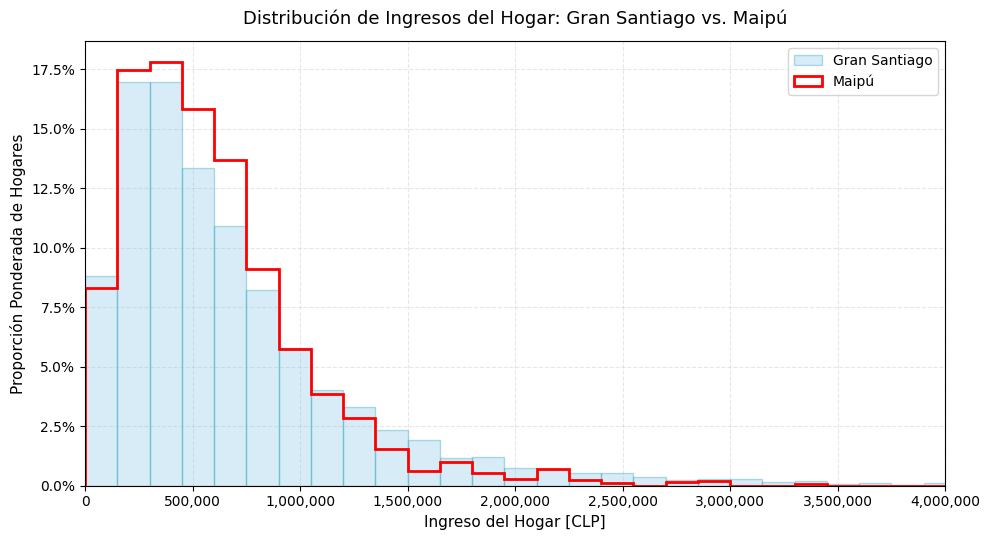

In [16]:
from matplotlib.ticker import FuncFormatter
import numpy as np

# 1. Limpiar nulos explícitamente y extraer arrays
clean_stgo = hogares[['IngresoHogar', 'Factor']].dropna()
clean_maipu = hogaresMaipu[['IngresoHogar', 'Factor']].dropna()

# 2. Definir cortes de bins uniformes
max_ingreso = 4_000_000
ancho_bin = 150_000
bins = np.arange(0, max_ingreso + ancho_bin, ancho_bin)

# 3. Ponderaciones normalizadas para que sumen 1 (stat='probability')
weights_stgo = clean_stgo['Factor'] / clean_stgo['Factor'].sum()
weights_maipu = clean_maipu['Factor'] / clean_maipu['Factor'].sum()

plt.figure(figsize=(10, 5.5))

# Histograma Gran Santiago (barras rellenas grises)
plt.hist(
    clean_stgo['IngresoHogar'],
    bins=bins,
    weights=weights_stgo,
    color='#8ecae6',
    alpha=0.35,
    label='Gran Santiago',
    edgecolor='#219ebc'
)

# Histograma Maipú (contorno tipo step visible)
plt.hist(
    clean_maipu['IngresoHogar'],
    bins=bins,
    weights=weights_maipu,
    color='red',
    histtype='step',
    linewidth=2,
    label='Maipú'
)

# Rótulos y unidades requeridas
plt.title('Distribución de Ingresos del Hogar: Gran Santiago vs. Maipú', fontsize=13, pad=12)
plt.xlabel('Ingreso del Hogar [CLP]', fontsize=11)
plt.ylabel('Proporción Ponderada de Hogares', fontsize=11)

plt.xlim(0, max_ingreso)
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.1f}%'))
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

**Interpretación:** Se eligió el histograma clasico por sobre bloxplot, KDE y el ECDF  debido a que se considera mas ilustrativa, sencillo y facil de leer a simple vista; ademas de evidenciar de forma sencilla donde estan mas concentrados los datos y en la diferencia entre Maipu y el Gran Santiago.

### 6. La comuna de contraste (8 pts)

**Instrucciones**

Elijan una comuna con un perfil de movilidad distinto al de la suya y
justifiquen la elección con datos; una cifra basta.

Calculen el reparto modal ponderado de las tres unidades: su comuna, la de
contraste y el Gran Santiago. El modo de cada viaje está en `ViajesDifusion.csv`
(llave `Viaje`) y su catálogo en `tablas_parametros/ModoDifusion.csv`; un viaje
pertenece a la comuna de su origen y el peso es `FactorLaboralNormal`.

Muestren las tres unidades en una sola figura.

En la interpretación, lean el contraste entre las tres unidades.

In [17]:
# Su código (agreguen las celdas que necesiten)
viajesDifusion = pd.read_csv(RUTA + "ViajesDifusion.csv", sep=";", decimal=",", low_memory=False, encoding="latin-1")
viajesCompleto_lab = pd.merge(viajes_lab, viajesDifusion, on="Viaje", how="left")

In [18]:
viajesCompletoMaipu_lab = viajesCompleto_lab[viajesCompleto_lab['ComunaOrigen'] == 94]
auto_maipu = (viajesCompletoMaipu_lab[viajesCompletoMaipu_lab['ComunaDestino'] == 94]['FactorLaboralNormal'].sum() / viajesCompletoMaipu_lab['FactorLaboralNormal'].sum()) * 100

viajesCompletoNunoa_lab = viajesCompleto_lab[viajesCompleto_lab['ComunaOrigen'] == 91]
auto_nunoa = (viajesCompletoNunoa_lab[viajesCompletoNunoa_lab['ComunaDestino'] == 91]['FactorLaboralNormal'].sum() / viajesCompletoNunoa_lab['FactorLaboralNormal'].sum()) * 100

print(f"Autocontención (viajes internos) Maipú: {auto_maipu:.1f}%")
print(f"Autocontención (viajes internos) Ñuñoa: {auto_nunoa:.1f}%")

Autocontención (viajes internos) Maipú: 67.1%
Autocontención (viajes internos) Ñuñoa: 41.5%


Se elige la comuna de Ñuñoa como contraste debido al rol geográfico y funcional opuesto que tienen ambas comunas. Maipú, al ser más periférica, presenta una alta tasa de autocontención del 67,1% (generando su propia dinámica local de viajes), mientras que Ñuñoa, al ser un punto céntrico e integrado a otras comunas, solo retiene el 41,5% de sus viajes, lo que anticipa patrones de movilidad y reparto modal claramente distintos.

In [19]:
repartoCompleto = (
    viajesCompleto_lab.groupby('ModoDifusion')['FactorLaboralNormal']
    .sum()
    .div(viajesCompleto_lab['FactorLaboralNormal'].sum())
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

repartoCompletoMaipu = (
    viajesCompletoMaipu_lab.groupby('ModoDifusion')['FactorLaboralNormal']
    .sum()
    .div(viajesCompletoMaipu_lab['FactorLaboralNormal'].sum())
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

repartoCompletoNunoa = (
    viajesCompletoNunoa_lab.groupby('ModoDifusion')['FactorLaboralNormal']
    .sum()
    .div(viajesCompletoNunoa_lab['FactorLaboralNormal'].sum())
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

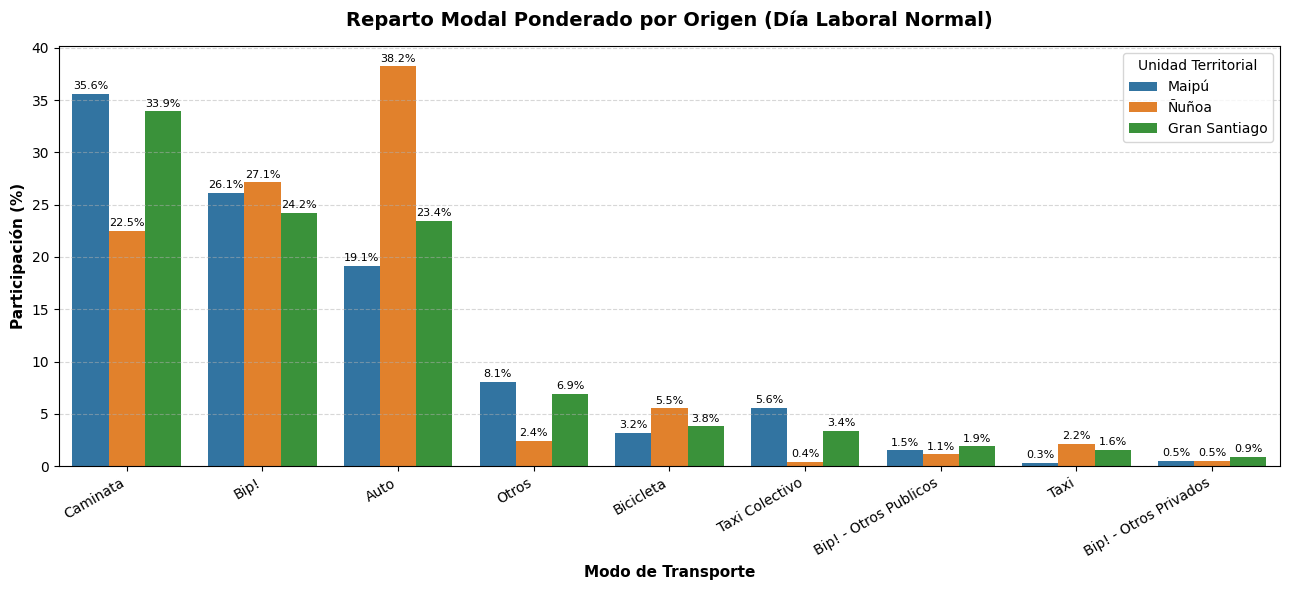

In [20]:
import seaborn as sns
dicc_modos = {
    1: 'Auto',
    2: 'Bip!',
    3: 'Taxi Colectivo',
    4: 'Taxi',
    5: 'Bip! - Otros Publicos',
    6: 'Bip! - Otros Privados',
    7: 'Otros',
    8: 'Caminata',
    9: 'Bicicleta'
}

# 1. Asegurar la reasignación de los nombres con el diccionario
rep_stgo = repartoCompleto.rename(index=dicc_modos).reset_index()
rep_stgo.columns = ['Modo', 'Porcentaje']
rep_stgo['Unidad'] = 'Gran Santiago'

rep_maipu = repartoCompletoMaipu.rename(index=dicc_modos).reset_index()
rep_maipu.columns = ['Modo', 'Porcentaje']
rep_maipu['Unidad'] = 'Maipú'

rep_nunoa = repartoCompletoNunoa.rename(index=dicc_modos).reset_index()
rep_nunoa.columns = ['Modo', 'Porcentaje']
rep_nunoa['Unidad'] = 'Ñuñoa'

# 2. Consolidar en un solo DataFrame para graficar
df_plot = pd.concat([rep_maipu, rep_nunoa, rep_stgo], ignore_index=True)

# 3. Ordenar las categorías en el eje X según el orden general del Gran Santiago
orden_modos = rep_stgo.sort_values('Porcentaje', ascending=False)['Modo'].tolist()

# 4. Graficar en una sola figura
plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=df_plot,
    x='Modo',
    y='Porcentaje',
    hue='Unidad',
    order=orden_modos,
    palette=['#1f77b4', '#ff7f0e', '#2ca02c']
)

# Estética y etiquetas
plt.title('Reparto Modal Ponderado por Origen (Día Laboral Normal)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Modo de Transporte', fontsize=11, weight='bold')
plt.ylabel('Participación (%)', fontsize=11, weight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Unidad Territorial', frameon=True)

# mostrar valores encima de las barras
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', 
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom', fontsize=8, rotation=0, xytext=(0, 2),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretación:** Tanto Maipu como el Gran Santiago tienen comportamientos similares en el modo de transporte, lo cual indica que la mayor parte de los viajes vienen asociados a ubicaciones perifericas; en cambio una comuna con una ubicacion estrategica como lo es Ñuñoa muestra modos de viaje distintos que pueden estar asociados a la cercania de sus destinos y la capacidad adquisitiva de las personas de ese sector.

### 7. Ingreso y transporte público (8 pts)

**Instrucciones**

Para todas las comunas del Gran Santiago calculen dos series: el ingreso medio
ponderado de los hogares (`IngresoHogar` con `Factor`) y la proporción ponderada
de viajes en transporte público. Decidan qué modos de `ModoDifusion` cuentan
como transporte público y declárenlo; el peso de los viajes es
`FactorLaboralNormal`.

Grafiquen una serie contra la otra, con cada comuna como un punto, destacando la
suya y la de contraste. Calculen las correlaciones de Pearson y de Spearman
entre ambas series.

En la interpretación: ¿qué indica la diferencia entre los dos coeficientes?
¿Qué comunas se apartan del patrón general, y dónde queda la suya?

Se considerarán como transporte público los modos _Bip!_, _Taxi colectivo_ y _Bip! - Otros Publicos_

Número de comunas analizadas: 38
Pearson:  -0.089 (p = 0.5947)
Spearman: 0.120 (p = 0.4737)


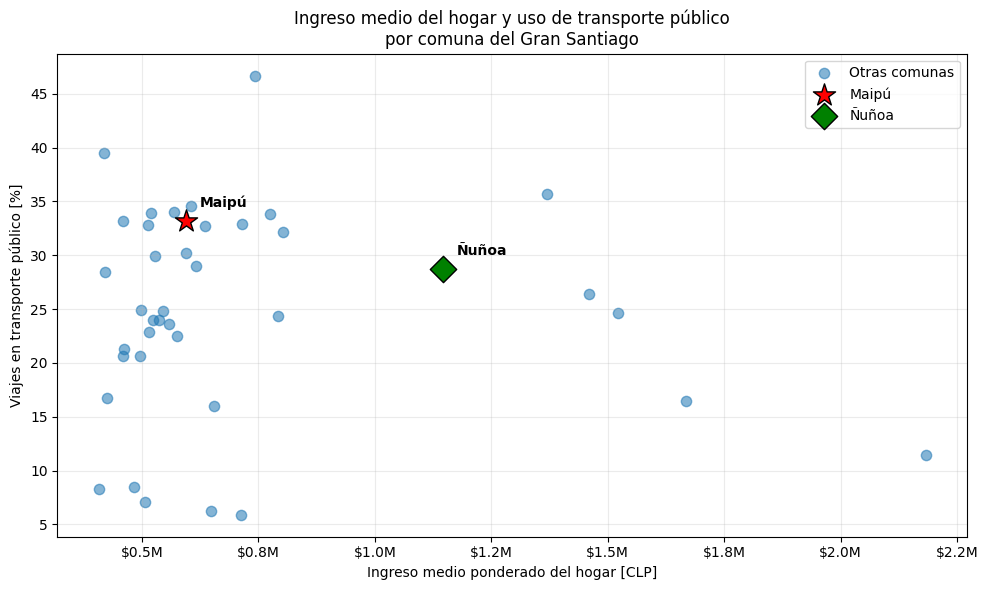

In [ ]:
# Su código (agreguen las celdas que necesiten)
import scipy.stats as stats

modos_tp = [2, 3, 5]


# ==============================================================================
# 1. PROPORCIÓN PONDERADA DE VIAJES EN TRANSPORTE PÚBLICO POR COMUNA
# ==============================================================================

v = viajesCompleto_lab[
    ['ComunaOrigen', 'ModoDifusion', 'FactorLaboralNormal']
].dropna().copy()

v['FactorTP'] = (
    v['FactorLaboralNormal']
    * v['ModoDifusion'].isin(modos_tp)
)

tp = (
    v.groupby('ComunaOrigen')
     .agg(
         total=('FactorLaboralNormal', 'sum'),
         publico=('FactorTP', 'sum')
     )
     .reset_index()
)

tp['Prop_TP'] = 100 * tp['publico'] / tp['total']

tp['CodigoComuna'] = pd.to_numeric(
    tp['ComunaOrigen'],
    errors='coerce'
)

tp = tp.dropna(subset=['CodigoComuna'])
tp['CodigoComuna'] = tp['CodigoComuna'].astype(int)


# ==============================================================================
# 2. INGRESO MEDIO PONDERADO POR COMUNA
# ==============================================================================

h = hogares[
    ['Comuna', 'IngresoHogar', 'Factor']
].dropna().copy()

h['IngresoPond'] = h['IngresoHogar'] * h['Factor']

ingreso = (
    h.groupby('Comuna')
     .agg(
         ingreso_pond=('IngresoPond', 'sum'),
         factor=('Factor', 'sum')
     )
     .reset_index()
)

ingreso['IngresoMedio'] = (
    ingreso['ingreso_pond'] / ingreso['factor']
)


# ==============================================================================
# 3. TRADUCIR NOMBRE DE COMUNA A CÓDIGO
# ==============================================================================

tabla_comunas = pd.read_csv(
    RUTA + 'tablas_parametros/Comuna.csv',
    sep=',',
    encoding='latin-1'
)


def normalizar(serie):
    return (
        serie.astype(str)
             .str.strip()
             .str.upper()
             .str.normalize('NFKD')
             .str.encode('ascii', errors='ignore')
             .str.decode('ascii')
    )


ingreso['nombre_norm'] = normalizar(ingreso['Comuna'])

# Detectar columna con nombres de comuna
nombres_hogares = set(ingreso['nombre_norm'])

col_nombre = max(
    tabla_comunas.columns,
    key=lambda c: len(
        set(normalizar(tabla_comunas[c])) & nombres_hogares
    )
)


# Detectar columna con códigos de comuna
codigos_origen = set(tp['CodigoComuna'])


def coincidencias_codigo(columna):
    valores = pd.to_numeric(
        tabla_comunas[columna],
        errors='coerce'
    ).dropna().astype(int)

    return len(set(valores) & codigos_origen)


col_codigo = max(
    tabla_comunas.columns,
    key=coincidencias_codigo
)


mapa_comunas = tabla_comunas[
    [col_nombre, col_codigo]
].copy()

mapa_comunas['nombre_norm'] = normalizar(
    mapa_comunas[col_nombre]
)

mapa_comunas['CodigoComuna'] = pd.to_numeric(
    mapa_comunas[col_codigo],
    errors='coerce'
)

mapa_comunas = (
    mapa_comunas
    .dropna(subset=['CodigoComuna'])
    .drop_duplicates(subset='nombre_norm')
)

mapa_comunas['CodigoComuna'] = (
    mapa_comunas['CodigoComuna'].astype(int)
)


# ==============================================================================
# 4. UNIR INGRESO Y TRANSPORTE PÚBLICO
# ==============================================================================

df_analisis = (
    ingreso
    .merge(
        mapa_comunas[['nombre_norm', 'CodigoComuna']],
        on='nombre_norm',
        how='inner'
    )
    .merge(
        tp[['CodigoComuna', 'Prop_TP']],
        on='CodigoComuna',
        how='inner'
    )
)

df_analisis = df_analisis.dropna(
    subset=['IngresoMedio', 'Prop_TP']
)


# ==============================================================================
# 5. CORRELACIONES
# ==============================================================================

r_pearson, p_pearson = stats.pearsonr(
    df_analisis['IngresoMedio'],
    df_analisis['Prop_TP']
)

r_spearman, p_spearman = stats.spearmanr(
    df_analisis['IngresoMedio'],
    df_analisis['Prop_TP']
)

print(f"Número de comunas analizadas: {len(df_analisis)}")
print(f"Pearson:  {r_pearson:.3f} (p = {p_pearson:.4f})")
print(f"Spearman: {r_spearman:.3f} (p = {p_spearman:.4f})")


# ==============================================================================
# 6. VALORES DE MAIPÚ Y ÑUÑOA
# ==============================================================================

# Maipú:
# ya calculaste su ingreso medio ponderado en la sección 3
ingreso_maipu = mediaMSueldos

# Ñuñoa:
# este valor no se había calculado anteriormente
ingreso_nunoa = np.average(
    hogaresNunoa['IngresoHogar'],
    weights=hogaresNunoa['Factor']
)

# El reparto modal ponderado de ambas comunas ya se calculó en la sección 6.
# Solo sumamos los modos que declaramos como transporte público.
tp_maipu = repartoCompletoMaipu.reindex(
    modos_tp,
    fill_value=0
).sum()

tp_nunoa = repartoCompletoNunoa.reindex(
    modos_tp,
    fill_value=0
).sum()

# ==============================================================================
# 7. GRÁFICO
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 6))


# Todas las comunas
ax.scatter(
    df_analisis['IngresoMedio'],
    df_analisis['Prop_TP'],
    alpha=0.55,
    s=55,
    label='Otras comunas'
)


# Maipú
ax.scatter(
    ingreso_maipu,
    tp_maipu,
    s=280,
    marker='*',
    color='red',
    edgecolor='black',
    linewidth=1,
    label='Maipú',
    zorder=10
)


# Ñuñoa
ax.scatter(
    ingreso_nunoa,
    tp_nunoa,
    s=180,
    marker='D',
    color='green',
    edgecolor='black',
    linewidth=1,
    label='Ñuñoa',
    zorder=10
)


# Etiqueta Maipú
ax.annotate(
    'Maipú',
    (ingreso_maipu, tp_maipu),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)


# Etiqueta Ñuñoa
ax.annotate(
    'Ñuñoa',
    (ingreso_nunoa, tp_nunoa),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    fontweight='bold'
)


# Título y ejes
ax.set_title(
    'Ingreso medio del hogar y uso de transporte público\n'
    'por comuna del Gran Santiago'
)

ax.set_xlabel(
    'Ingreso medio ponderado del hogar [CLP]'
)

ax.set_ylabel(
    'Viajes en transporte público [%]'
)


# Formato del eje de ingresos
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f'${x / 1_000_000:.1f}M'
    )
)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

¿qué indica la diferencia entre los dos coeficientes?
¿Qué comunas se apartan del patrón general, y dónde queda la suya?


**Interpretación:** El coeficiente de Pearson tiene un valor negativo representando que hay una relacion negativa entre el ingreso y el porcentaje de viajes en transporte publico, indicando que a nivel Santiago entre mas ingreso menos se usa el trnasporte publico pero debido a que el coeficiente tuvo un valor de -0.089 no se puede respaldar la relacion lineal dicha. Con Spearman dio signo positivo indicando que hay una relacion monotona creciente entre las variables pero al tener un valor de 0.120, siendo muy cercano a 0, la relacion creciente no es fiable para este par de variables.

Ñuñoa marca el inicio de las comunas que se aleja de la nube de datos de la izquierda y estan aquellas qie tienen el mayor ingreso medio. La comuna de Maipú se encuentra en el medio de la nube de datos de la izquierda con un ingreso medio cecano al de Santiago.

### 8. Un hallazgo propio (6 pts)

**Instrucciones**

Agreguen un gráfico a elección que muestre algo del retrato que los ítems
anteriores no capturan, ponderado como todo lo demás. Se evalúa que el hallazgo
no sea trivial: que no repita lo ya visto ni muestre algo obvio.

En la interpretación, escriban la lectura del hallazgo en dos o tres líneas.

In [22]:
# Su código (agreguen las celdas que necesiten)


**Interpretación:** *(reemplacen este texto por su respuesta)*

## Parte 3. Decisiones sobre los datos (25 puntos)

### 9. Los que faltan (8 pts)

**Instrucciones**

Identifiquen los datos faltantes que afectan su retrato: al menos
`IngresoHogar`, los factores de expansión, `TiempoViaje` y las coordenadas.
Determinen si esos faltantes siguen algún patrón (por ejemplo, si se concentran
en algún grupo o comuna) o si pueden tratarse como ausencias sin estructura, y
muestren la evidencia. Recuerden lo visto en clase: un `NaN` en los factores no
es un error, significa que esa persona no pertenece a ese universo.

Declaren qué decidieron hacer con los faltantes y recalculen una de las cifras
de su retrato con la decisión contraria, para mostrar cuánto cambia.

In [23]:
# Su código (agreguen las celdas que necesiten)


**Interpretación:** *(reemplacen este texto por su respuesta)*

### 10. Los extremos (8 pts)

**Instrucciones**

Busquen valores extremos o sospechosos en las duraciones (`TiempoViaje`) y en
las distancias de los viajes con origen en su comuna. La distancia está en
`DistanciaViaje.csv`, con llave `Viaje` y expresada en metros.

Cuantifíquenlos con algún criterio explícito: la regla de Tukey del boxplot, el
criterio de desviaciones estándar respecto de la media (por ejemplo, tres
sigmas), u otro que conozcan y justifiquen.

Investíguenlos: ¿son errores de registro o viajes reales posibles? Declaren la
decisión que tomaron (mantener, corregir o excluir) y muestren su efecto sobre
las medidas que reportaron, por ejemplo comparando la media y la mediana con y
sin ellos.

In [24]:
# Su código (agreguen las celdas que necesiten)


**Interpretación:** *(reemplacen este texto por su respuesta)*

### 11. Una transformación (9 pts)

**Instrucciones**

Apliquen una transformación justificada a una variable de su retrato, por
ejemplo el logaritmo al ingreso o a la duración.

Muestren el efecto con un gráfico del antes y el después.

En la interpretación, expliquen cómo cambia la forma de la distribución y qué
medidas se vuelven más o menos informativas después de la transformación.

In [25]:
# Su código (agreguen las celdas que necesiten)


**Interpretación:** *(reemplacen este texto por su respuesta)*

## Parte 4. Síntesis (20 puntos)

### 12. El retrato (8 pts)

**Instrucciones**

- Escriban aquí "El retrato de [su comuna]" en **máximo 10 líneas**, integrando
  los hallazgos numéricos y gráficos de toda la tarea.
- Debe poder leerse sola, sin el resto del notebook: con cifras concretas, no
  con referencias a "el gráfico anterior".

*(reemplacen este texto por su retrato)*

### 13. ¿De quién hablan sus números? (6 pts)

**Instrucciones**

- ¿Sus cifras hablan de la muestra, de su comuna, de la ciudad? ¿De qué días y
  temporada, dado el universo que declararon?
- ¿Qué personas o viajes podrían estar quedando fuera del retrato? Piensen en
  quién responde una encuesta presencial de 2012 y quién no.

*(reemplacen este texto por su respuesta)*

### 14. Una hipótesis para más adelante (6 pts)

**Instrucciones**

- Formulen una hipótesis **verificable** que su exploración sugiere pero no
  demuestra (por ejemplo, sobre la relación entre dos variables de su comuna).
- Se evalúa que sea precisa, comprobable y motivada por sus datos. 



In [26]:
*(reemplacen este texto por su hipótesis y su motivación en 2 a 4 líneas)*

SyntaxError: invalid syntax. Perhaps you forgot a comma? (641662063.py, line 1)

## Declaración de uso de IA generativa

*(reemplacen este texto: qué herramienta usaron y para qué; una línea basta.
Recuerden que deben poder explicar cualquier línea de su código si se les
pregunta en clase.)*

## Antes de entregar

- [ ] El notebook corre de principio a fin sin errores.
- [ ] `MI_COMUNA` y `COMUNA_CONTRASTE` están definidas.
- [ ] Toda cifra poblacional está ponderada y su universo está declarado.
- [ ] Todos los gráficos tienen título y ejes rotulados con unidades.
- [ ] Todas las celdas de "Interpretación" están completas.
- [ ] El archivo se llama `tarea1_apellido1_apellido2.ipynb`.
- [ ] La declaración de uso de IA está completa.